# Data Project

> **Note:** 
> 1. This is a starting point for how to structure your data project 
> 1. The `dataproject.py` file includes functions which can be in this notebook

Import and set magics:

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import dataproject

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Question 1

We load the data from Danmarks Statistik, and lookup the table variables

In [104]:
from dstapi import DstApi

pris113 = DstApi('PRIS113')
print(pris113.tablesummary(language='en'))

Table PRIS113: Consumer price index by type and time
Last update: 2026-01-12T08:00:00
  variable name  # values First value     First value label Last value  \
0          TYPE         1      INDEKS  Consumer price index     INDEKS   
1           Tid       552     1980M01               1980M01    2025M12   

       Last value label  Time variable  
0  Consumer price index          False  
1               2025M12           True  


We lookup the parameter structure that 'DstApi' proposes

In [105]:
params = pris113.define_base_params(language='en')
print(params)

{'table': 'pris113', 'format': 'BULK', 'lang': 'en', 'variables': [{'code': 'TYPE', 'values': ['*']}, {'code': 'Tid', 'values': ['*']}]}


We would like to show the loaded DataFrame

In [106]:
data = pris113.get_data(params=params)
print(data.columns)
data.head()

Index(['TYPE', 'TID', 'INDHOLD'], dtype='str')


,TYPE,TID,INDHOLD
0,Consumer price index,1980M01,33.0
1,Consumer price index,1980M05,34.5
2,Consumer price index,1980M09,35.5
3,Consumer price index,1981M01,36.5
4,Consumer price index,1981M05,38.6


In [107]:
data['date'] = pd.to_datetime(data['TID'], format='%YM%m')
data = data.sort_values('date').reset_index(drop=True)
data.head()

,TYPE,TID,INDHOLD,date
0,Consumer price index,1980M01,33.0,1980-01-01
1,Consumer price index,1980M02,33.3,1980-02-01
2,Consumer price index,1980M03,33.8,1980-03-01
3,Consumer price index,1980M04,34.0,1980-04-01
4,Consumer price index,1980M05,34.5,1980-05-01


In [108]:
print(data['INDHOLD'].dtype)
print(data['INDHOLD'].head())

str
0    33.0
1    33.3
2    33.8
3    34.0
4    34.5
Name: INDHOLD, dtype: str


In [109]:
data['INDHOLD'] = data['INDHOLD'].astype(float)
print(data['INDHOLD'].dtype)
data.head()

float64


,TYPE,TID,INDHOLD,date
0,Consumer price index,1980M01,33.0,1980-01-01
1,Consumer price index,1980M02,33.3,1980-02-01
2,Consumer price index,1980M03,33.8,1980-03-01
3,Consumer price index,1980M04,34.0,1980-04-01
4,Consumer price index,1980M05,34.5,1980-05-01


In [110]:
mean_2020 = data.loc[data['date'].dt.year == 2020, 'INDHOLD'].mean()
print(mean_2020)

data['CPI_indexed'] = data['INDHOLD'] / mean_2020 * 100
data.tail()

103.43333333333334


,TYPE,TID,INDHOLD,date,CPI_indexed
547,Consumer price index,2025M08,121.7,2025-08-01,117.660329
548,Consumer price index,2025M09,121.6,2025-09-01,117.563648
549,Consumer price index,2025M10,122.1,2025-10-01,118.047051
550,Consumer price index,2025M11,121.7,2025-11-01,117.660329
551,Consumer price index,2025M12,121.2,2025-12-01,117.176926


In [111]:
data['inflation_mom'] = data['CPI_indexed'].pct_change(periods=1)
data['inflation_12m'] = data['CPI_indexed'].pct_change(periods=12)

data.tail(15)

,TYPE,TID,INDHOLD,date,CPI_indexed,inflation_mom,inflation_12m
537,Consumer price index,2024M10,119.6,2024-10-01,115.630035,0.005887,0.016143
538,Consumer price index,2024M11,119.2,2024-11-01,115.243313,-0.003344,0.016198
539,Consumer price index,2024M12,118.9,2024-12-01,114.953271,-0.002517,0.018852
540,Consumer price index,2025M01,119.6,2025-01-01,115.630035,0.005887,0.015280
541,Consumer price index,2025M02,120.8,2025-02-01,116.790203,0.010033,0.020270
542,Consumer price index,2025M03,120.2,2025-03-01,116.210119,-0.004967,0.015203
543,Consumer price index,2025M04,120.3,2025-04-01,116.306800,0.000832,0.015190
544,Consumer price index,2025M05,120.4,2025-05-01,116.403481,0.000831,0.016034
545,Consumer price index,2025M06,120.7,2025-06-01,116.693522,0.002492,0.018565
546,Consumer price index,2025M07,122.5,2025-07-01,118.433774,0.014913,0.022538


Text(0, 0.5, 'CPI (indeks)')

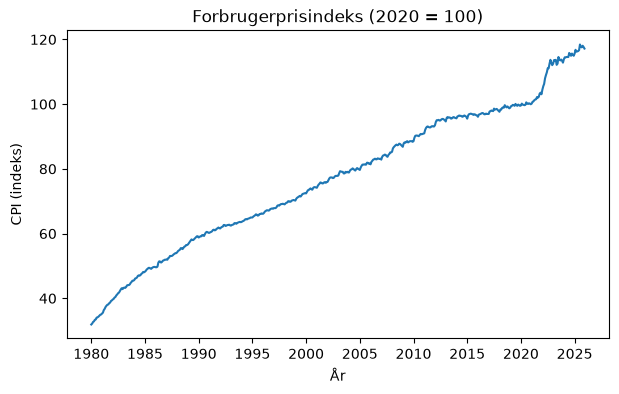

In [112]:
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

ax.plot(data['date'], data['CPI_indexed'])

ax.set_title('Forbrugerprisindeks (2020 = 100)')
ax.set_xlabel('År')
ax.set_ylabel('CPI (indeks)')

In [113]:
data = dataproject.load_data()

## Question 2

We process the data by ...

In [114]:
data = dataproject.process_data(data)

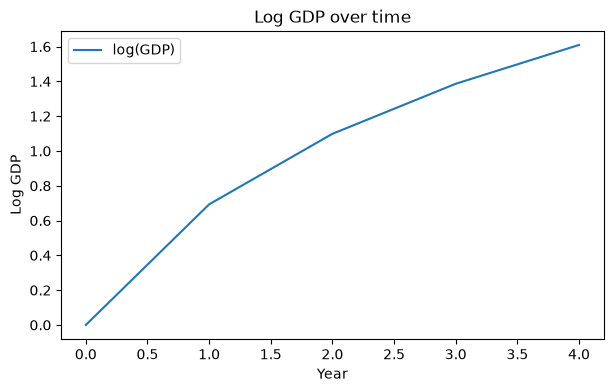

In [115]:
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

ax.plot(data['log_GDP'],label='log(GDP)')

ax.set_title('Log GDP over time')
ax.set_xlabel('Year')
ax.set_ylabel('Log GDP')

ax.legend();

We find that that ...

Lookup table variables